# 社會網絡分析與地理應用 第十一週作業

資訊工程學系 三年級 吳佳泰 S1254059

## 1. 請設計一個 Python 的 function，使用者輸入一個 graph 之後，function 可以判斷此 graph 是否為 complete graph

In [2]:
import networkx as nx
import heapq

from operator import itemgetter


opt	Graph
1	Karate club graph
2	Complete graph with n node
3	Make a graph by yourself
Your choose : 2. complete graph with 5 nodes.
Outcome : True


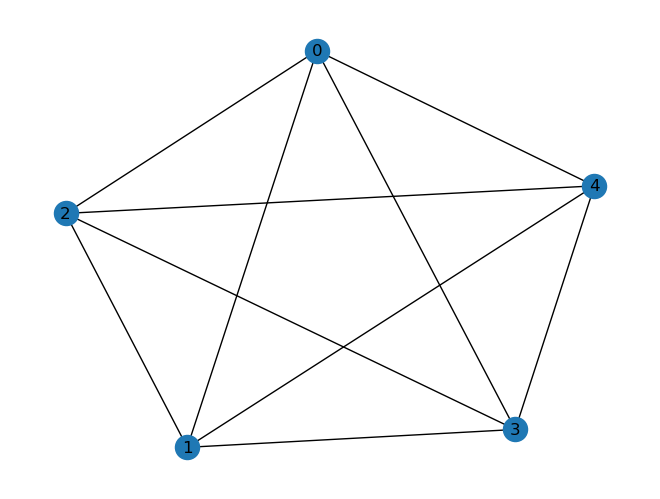

In [ ]:
def check_complete_graph (g: nx.Graph):
    node = list(g.nodes())
    edge = list(g.edges())
    
    for i in range(len(node)):
        for j in range(i+1, len(node)):
            if ((node[i], node[j]) not in edge):
                return False

    return True



print("opt", "Graph", sep="\t")
print("1", "Karate club graph", sep="\t")
print("2", "Complete graph with n node", sep="\t")
print("3", "Make a graph by yourself", sep="\t")

choose = int(input("Please choose a graph :"))

if (choose == 1):
    g = nx.karate_club_graph()
    print("Your choose : 1. Karate club graph")

elif (choose == 2):
    n = int(input("Please input number of nodes (n) :"))
    g = nx.complete_graph(n)
    print("Your choose : 2. complete graph with", n, "nodes.")

elif (choose == 3):
    print("Please input all node (all nodes are sparated by commas, e.g. A,B,C).")
    node = input("Input nodes :").split(",")
    
    print("Please input all edge (two nodes are sparated by hyphen, and two edges are sparated by commas, e.g. A-B,B-C,C-A) ")
    edges = input("Input edges :").split(",")
    edge = [(i.split("-")) for i in edges]

    g = nx.Graph()
    g.add_nodes_from(node)
    g.add_edges_from(edge)

    print("Your choose : 3. Your graph")
    print("Your nodes :", node)
    print("Your edges :", edge)

print("Outcome :", check_complete_graph(g))
nx.draw(g, with_labels=True)


## 2. 請利用 Dijkstra 演算法，針對空手道俱樂部的網絡，計算每一個節點的 closeness centrality；並與 networkx 內建的指令做對比

In [26]:
def dijkstra(g: nx.Graph, start: int):
    distance = {node: float("inf") for node in g.nodes()}
    path = {node: 0 for node in g.nodes()}
    before_node = {node: [] for node in g.nodes()}

    distance[start] = 0
    path[start] = 1

    heap = [(0, start)]
    stack = []
    visit = set()

    while (heap):
        d, n = heapq.heappop(heap)

        if (d > distance[n]):
            continue

        if (n not in visit):
            stack.append(n)
            visit.add(n)

        for i in g.neighbors(n):
            weight = g[n][i].get("weight", 1) 
            new_distance = d + weight

            if (new_distance < distance[i]):
                distance[i] = new_distance
                heapq.heappush(heap, (new_distance, i))

                path[i] = path[n]
                before_node[i] = [n]

            elif (new_distance == distance[i]):
                path[i] += path[n]
                before_node[i].append(n)
    
    return distance, path, before_node, stack

node  dijkstra       networkx       outcome   
0     0.253846       0.253846       True      
1     0.200000       0.200000       True      
2     0.196429       0.196429       True      
3     0.176471       0.176471       True      
4     0.152778       0.152778       True      
5     0.152074       0.152074       True      
6     0.153488       0.153488       True      
7     0.182320       0.182320       True      
8     0.198795       0.198795       True      
9     0.190751       0.190751       True      
10    0.175532       0.175532       True      
11    0.146018       0.146018       True      
12    0.204969       0.204969       True      
13    0.190751       0.190751       True      
14    0.170984       0.170984       True      
15    0.137500       0.137500       True      
16    0.108553       0.108553       True      
17    0.192982       0.192982       True      
18    0.187500       0.187500       True      
19    0.248120       0.248120       True      
20    0.20370

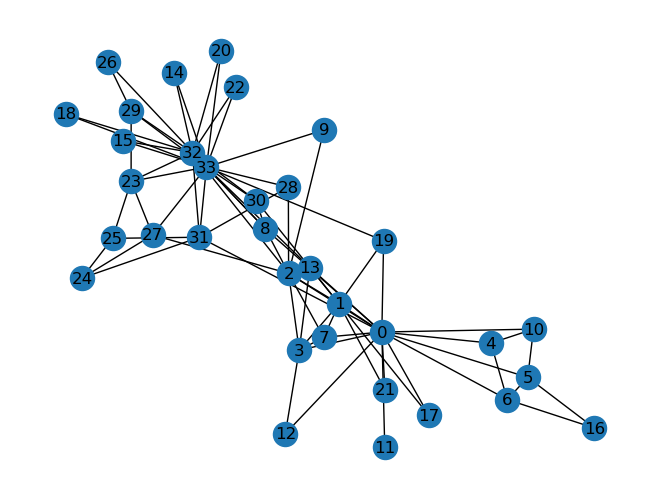

In [27]:
def closeness_centrality(g: nx.Graph):
    closeness = {}
    n = len(g.nodes())

    for i in g.nodes():
        distance, path, before_node, stack = dijkstra(g, i)
        total = sum(distance.values())

        if (total > 0):
            closeness[i] = (n - 1) / total
        else:
            closeness[i] = 0

    return closeness

g = nx.karate_club_graph()
dij_closeness = closeness_centrality(g)
nx_closeness = nx.closeness_centrality(g, distance="weight")

print("{:<6}{:<15}{:<15}{:<10}".format("node", "dijkstra", "networkx", "outcome"))
for i in g.nodes():
    print("{:<6}{:<15.6f}{:<15.6f}{:<10}".format(i, dij_closeness[i], nx_closeness[i], str(abs(dij_closeness[i] - nx_closeness[i]) < 1e-6)))

nx.draw(g, with_labels=True)
    


## 3. 請利用 Dijkstra 演算法，針對空手道俱樂部的網絡，計算每一個節點的 betweenness centrality；並與 networkx 內建的指令做對比

node  dijkstra       networkx       outcome   
0     0.473769       0.473769       True      
1     0.064015       0.064015       True      
2     0.069413       0.069413       True      
3     0.002525       0.002525       True      
4     0.000947       0.000947       True      
5     0.029356       0.029356       True      
6     0.029356       0.029356       True      
7     0.000000       0.000000       True      
8     0.024811       0.024811       True      
9     0.013794       0.013794       True      
10    0.000947       0.000947       True      
11    0.000000       0.000000       True      
12    0.000000       0.000000       True      
13    0.002273       0.002273       True      
14    0.000000       0.000000       True      
15    0.000000       0.000000       True      
16    0.000000       0.000000       True      
17    0.030492       0.030492       True      
18    0.005682       0.005682       True      
19    0.240657       0.240657       True      
20    0.00000

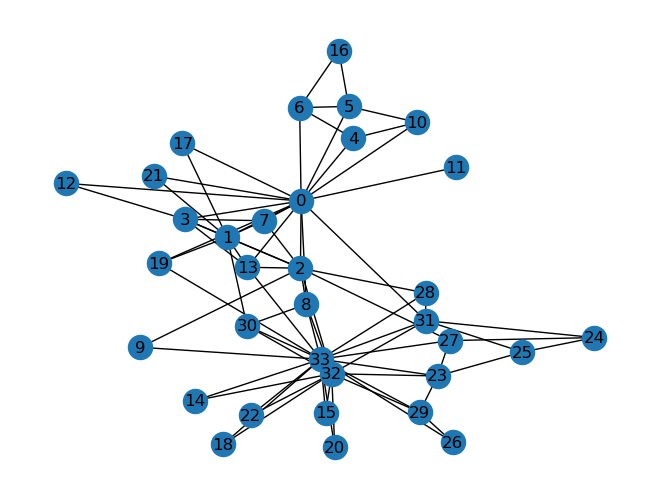

In [30]:
def betweenness_centrality(g: nx.Graph):
    betweenness = {node: 0 for node in g.nodes()}

    for i in g.nodes():
        distance, path, before_node, stack = dijkstra(g, i)
        dict1 = {node: 0 for node in g.nodes()}

        while (stack):
            a = stack.pop()

            for j in before_node[a]:
                dict1[j] += (path[j] / path[a]) * (1 + dict1[a])

            if (i != a):
                betweenness[a] += dict1[a]

    for i in betweenness:
        betweenness[i] /= ((len(g.nodes()) - 1) * (len(g.nodes()) - 2))

    return betweenness

g = nx.karate_club_graph()
dij_betweenness = betweenness_centrality(g)
nx_betweenness = nx.betweenness_centrality(g, normalized=True, weight="weight")

print("{:<6}{:<15}{:<15}{:<10}".format("node", "dijkstra", "networkx", "outcome"))
for i in g.nodes():
    print("{:<6}{:<15.6f}{:<15.6f}{:<10}".format(i, dij_betweenness[i], nx_betweenness[i], str(abs(dij_betweenness[i] - nx_betweenness[i]) < 1e-6)))

nx.draw(g, with_labels=True)